# Workspace — [김채영] [실험 2]

**이 노트북은 깃에 안 올라감 (`.gitignore` 처리됨).** 자유롭게 사용.

작업 흐름:
1. 이 템플릿을 복사: `cp _template.ipynb 본인이름_그룹.ipynb`
2. 외부 데이터 로드 → 분석 → 변수 생성 코드 작성
3. 코드가 정리되면 `src/features.py`에 함수로 옮김
4. 채택/탈락 판단 + 근거 메모 (자기 작업 노트에)
5. PR로 `src/features.py` 변경분만 머지

## 1. 라이브러리 로드

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import sys
import os

import platform
if platform.system() == 'Darwin':
    matplotlib.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
else:
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

sys.path.append('../../src')
from features import add_features_unique  # 공용 헬퍼

## 2. 데이터 로드

In [19]:
# 전처리된 실거래가 (좌표 포함)
df = pd.read_csv('../../data/processed/apt_preprocessed.csv', encoding='utf-8-sig')

# 자기 담당 외부 데이터 로드
# external = pd.read_csv('../../data/raw/내데이터.csv', encoding='cp949')
subway = pd.read_csv('../../data/raw/지하철역.csv', encoding='utf-8-sig')
bus = pd.read_csv('../../data/raw/버스정류장.csv', encoding='cp949')

print(f'실거래가: {df.shape}')
print(f'지하철역: {subway.shape}')
print(f'버스정류장: {bus.shape}')

실거래가: (173399, 15)
지하철역: (407, 5)
버스정류장: (16980, 9)


## 3. 외부 데이터 탐색

컬럼 구조 확인, 위도/경도 컬럼명 파악, 결측치/이상치 점검.

In [20]:
print(df.columns.tolist())
print(subway.columns.tolist())
print(bus.columns.tolist())

display(subway.head())
display(bus.head())

['시군구', '단지명', '전용면적(㎡)', '계약년월', '계약일', '거래금액(만원)', '층', '건축년도', '도로명', '계약년도', '구', '강남권', '노후도', '위도', '경도']
['역사명', '노선명', '역위도', '역경도', '역사도로명주소']
['정류장번호', '정류장명', '위도', '경도', '정보수집일', '모바일단축번호', '도시코드', '도시명', '관리도시명']


,역사명,노선명,역위도,역경도,역사도로명주소
0,4.19민주묘지,우이신설선,37.649540,127.013710,서울특별시 강북구 삼양로 519
1,가락시장,3호선,37.492318,127.117700,서울특별시 송파구 송파대로 지하257(가락동)
2,가락시장,8호선,37.493004,127.118279,서울특별시 송파구 송파대로 지하257(가락동)
3,가산디지털단지역,경부선,37.481568,126.882628,서울시 금천구 벚꽃로 309
4,가산디지털단지,7호선,37.480376,126.882704,서울특별시 금천구 벚꽃로 309(가산동)


,정류장번호,정류장명,위도,경도,정보수집일,모바일단축번호,도시코드,도시명,관리도시명
0,GGB123000289,가락시장역4번출구.제일오피스텔,37.493233,127.119800,2025-10-31,24380,11,서울특별시,경기BIS
1,GGB123000291,경찰병원.서울동부고용노동지청,37.494417,127.122700,2025-10-31,24382,11,서울특별시,경기BIS
2,GGB123000294,가락시장.가락시장역,37.493833,127.117183,2025-10-31,24385,11,서울특별시,경기BIS
3,GGB123000295,가락시장.가락몰,37.491883,127.115850,2025-10-31,24386,11,서울특별시,경기BIS
4,GGB123000296,가락시장남문,37.490783,127.112367,2025-10-31,24387,11,서울특별시,경기BIS


## 4. 변수 생성 테스트

공용 헬퍼 함수로 빠르게 거리/카운트 변수 만들어 분석.

In [5]:
# 지하철 컬럼명 통일
subway = subway.rename(columns={
    '역위도': '위도',
    '역경도': '경도'
})

# 복사본 생성
df_test = df.copy()

# 지하철 변수 생성
df_test = add_features_unique(
    df_test,
    subway,
    'subway',
    radius=500
)

# 버스 변수 생성
df_test = add_features_unique(
    df_test,
    bus,
    'bus',
    radius=500
)

# 결과 확인
df_test[[
    'subway_nearest_dist',
    'subway_count_500m',
    'bus_nearest_dist',
    'bus_count_500m'
]].head()

[subway] 변수 추가 완료 (고유 단지 7051개 기준): subway_nearest_dist, subway_count_500m
[bus] 변수 추가 완료 (고유 단지 7051개 기준): bus_nearest_dist, bus_count_500m


,subway_nearest_dist,subway_count_500m,bus_nearest_dist,bus_count_500m
0,370.382129,1,50.147309,23
1,706.417044,0,105.393185,38
2,1388.429395,0,201.320210,12
3,177.268705,1,107.997351,29
4,491.640088,1,68.541688,16


## 5. EDA — 변수 분석

AI 활용 자유롭게.

- 변수 분포 (히스토그램, 박스플롯)
- 거래금액과의 산점도/상관관계
- 강남/비강남 비교
- 구간별 평균 가격
- 다른 변수와의 다중공선성

### 5-1 상관관계 보기

In [21]:
corr_cols = [
    'subway_nearest_dist',
    'subway_count_500m',
    'bus_nearest_dist',
    'bus_count_500m',
    '거래금액(만원)'
]

df_test[corr_cols].corr()

,subway_nearest_dist,subway_count_500m,bus_nearest_dist,bus_count_500m,거래금액(만원)
subway_nearest_dist,1.000000,-0.590999,-0.017079,-0.110694,-0.123772
subway_count_500m,-0.590999,1.000000,0.058787,0.174178,0.071305
bus_nearest_dist,-0.017079,0.058787,1.000000,-0.295644,0.095173
bus_count_500m,-0.110694,0.174178,-0.295644,1.000000,-0.175369
거래금액(만원),-0.123772,0.071305,0.095173,-0.175369,1.000000


### 5-2 히스토그램

<Axes: >

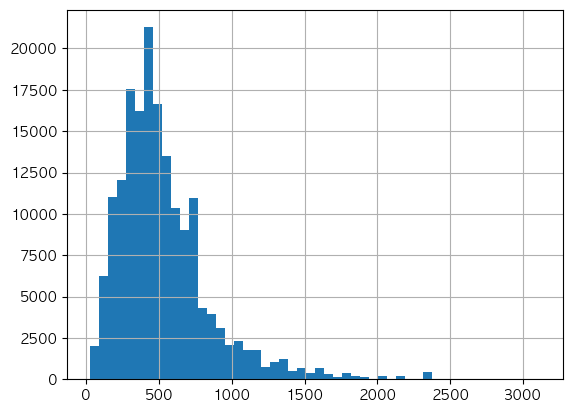

In [22]:
# 지하철 거리 분포
df_test['subway_nearest_dist'].hist(bins=50) 

<Axes: >

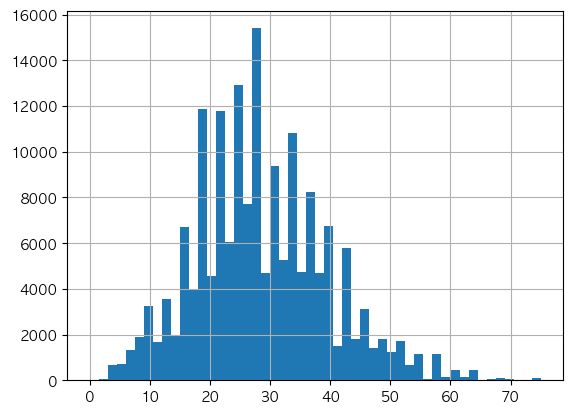

In [23]:
# 버스 개수 분포
df_test['bus_count_500m'].hist(bins=50)

### 5-3 산점도

<Axes: xlabel='subway_nearest_dist', ylabel='거래금액(만원)'>

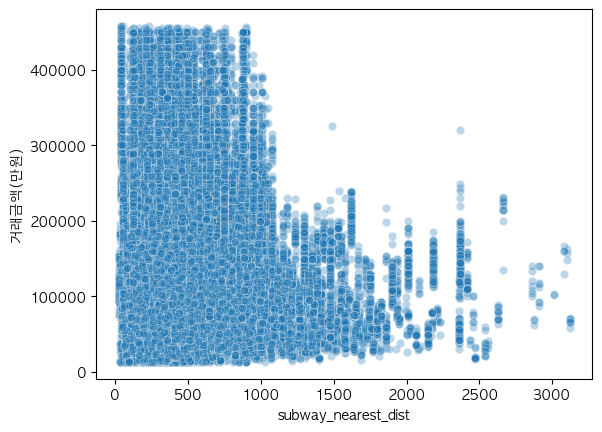

In [24]:
# 지하철 거리 vs 거래금액
sns.scatterplot(
    data=df_test,
    x='subway_nearest_dist',
    y='거래금액(만원)',
    alpha=0.3
)

### 5-4 구간별 평균 가격

In [25]:
df_test['subway_distance_group'] = pd.cut(
    df_test['subway_nearest_dist'],
    bins=[0, 300, 500, 1000, 2000, 5000],
    labels=['~300m', '300~500m', '500m~1km', '1~2km', '2km+']
)

df_test.groupby('subway_distance_group')['거래금액(만원)'].mean()

/var/folders/rt/lmyzhmj52lb3rmrs_2h25l9h0000gn/T/ipykernel_15528/1604607039.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test.groupby('subway_distance_group')['거래금액(만원)'].mean()


subway_distance_group
~300m       123711.646556
300~500m    121216.025359
500m~1km    115548.223645
1~2km        82960.149444
2km+         94275.661157
Name: 거래금액(만원), dtype: float64

In [29]:
# 분포
# df_test['prefix_nearest_dist'].hist(bins=50)

# 상관계수
# df_test[['prefix_nearest_dist', 'prefix_count_1000m', '거래금액(만원)']].corr()

# 산점도
# sns.scatterplot(data=df_test, x='prefix_nearest_dist', y='거래금액(만원)', alpha=0.3)

from pathlib import Path

save_file = Path('../../data/processed/apt_transport_features.csv')

print("현재 위치:", Path.cwd())
print("저장 위치:", save_file.resolve())

df_test.to_csv(save_file,
               index=False,
               encoding='utf-8-sig')

print("저장 완료")
print("파일 존재 여부:", save_file.exists())

현재 위치: /Users/chaeyk1104/Desktop/HSU/26-1/데이터마이닝/DM-AptPrice-Prediction-Project/notebooks/workspace
저장 위치: /Users/chaeyk1104/Desktop/HSU/26-1/데이터마이닝/DM-AptPrice-Prediction-Project/data/processed/apt_transport_features.csv
저장 완료
파일 존재 여부: True


In [27]:
import os
os.listdir('./data/processed')

['apt_transport_features.csv']

## 6. 채택/탈락 판단

분석 결과를 보고 어떤 변수를 채택할지 결정.

**참고:** 채택/탈락 근거는 자기 작업 노트(워드/노션/메모장 등)에 자유 양식으로 기록.
보고서 작성 시 그 노트를 가져와서 보고서에 옮긴다.

[채택]
1. subway_nearest_dist
- 거래금액과 음의 상관관계 확인
- 역세권일수록 평균 거래가격 높게 나타남
- 구간별 평균가격 분석 결과 명확한 차이 확인

2. subway_count_500m
- 주변 지하철 접근성 반영 가능
- 거래금액과 약한 양의 상관관계 확인

3. bus_nearest_dist
- 버스 접근성 변수로 활용 가능
- 일부 가격 영향 확인

[보류/탈락]
1. bus_count_500m
- 거래금액과 예상과 다른 방향의 상관관계
- 지역 밀집도/상업지역 영향 가능성 존재
- 추가 검증 필요

## 7. features.py에 함수로 옮기기

분석 결과를 토대로 채택한 변수만 함수로 정리하여 `src/features.py`에 추가.

예시:
```python
# src/features.py — 본인 담당 섹션에 추가

def add_my_features(df, my_df, radius=1000):
    """
    [내 변수 그룹] 변수 추가.

    추가 컬럼:
        - prefix_nearest_dist
        - prefix_count_{r}m
    """
    df = add_features_unique(df, my_df, 'prefix', radius=radius)
    return df
```

함수 시그니처 규약은 `src/features.py` 상단 주석 참조.